In [1]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path

In [2]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [3]:
cases = ["M1_A1_NE","R3","R4","S1_3"]
projects = ["scan_q","scan_shat","scan_beta"]

In [4]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.netcdf"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0000'. 
  warnings.warn(


Project: scan_q, Case: R3
Project: scan_q, Case: R4
Project: scan_q, Case: S1_3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0003) is inconsistent with value from physical reference values (0.09609377161346086 beta_ref_ee_B0_pyroscan_base0003)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0003'. 
  warnings.warn(


Project: scan_shat, Case: M1_A1_NE


...

Project: scan_shat, Case: R3
Project: scan_shat, Case: R4
Error loading gk output for scan_shat/R4: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html
Error loading gk output without netcdf for scan_shat/R4: Unable to load any gk_output files in this scan
Project: scan_shat, Case: S1_3


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyroscan.py:800: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.250/gs2.in [ValueError: File /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.250/gs2.out.nc not found.]
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyroscan.py:800: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.056/gs2.in [ValueError: File /mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_shat/R4/parameter_scan_GS2/ky0.100_shat-0.056/gs2.out.nc not found.]
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/pyroscan.py:800: UserWarning: Unable to load gk_output for /mnt/data/Gyrokinetic_Simu

Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/pyrokinetics/src/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0008'. 
  warnings.warn(


Project: scan_beta, Case: R3
Project: scan_beta, Case: R4
Project: scan_beta, Case: S1_3
Error loading pyroscan for scan_beta/S1_3: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/GS2/Runs/scan_beta/S1_3/parameter_scan_GS2/pyroscan.json'


In [5]:
tglf_versions = ["TGLF","tglf_v1","tglf_v2"]
tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            print(f"Project: {project}, Case: {case}")
            json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.json"))
            net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/parameter_scan_{version}/pyroscan.netcdf"))
            try:
                tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                try:
                    tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                    version_dict[version] = tglf_pyoscan
                except Exception as e:
                    print(f"Error loading gk output for {project}/{case}/{version}: {e}")
                    # try:
                    #     tglf_pyoscan.load_gk_output()
                    #     tglf_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    #     version_dict[version] = tglf_pyoscan
                    # except Exception as e:
                    #     print(f"Error loading gk output without netcdf for {project}/{case}/{version}: {e}")
            except Exception as e:
                print(f"Error loading pyroscan for {project}/{case}/{version}: {e}")
                continue
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: M1_A1_NE
Project: scan_q, Case: R3
Project: scan_q, Case: R3
Project: scan_q, Case: R3
Project: scan_q, Case: R4
Project: scan_q, Case: R4
Project: scan_q, Case: R4
Project: scan_q, Case: S1_3
Project: scan_q, Case: S1_3
Project: scan_q, Case: S1_3
Project: scan_shat, Case: M1_A1_NE
Project: scan_shat, Case: M1_A1_NE
Project: scan_shat, Case: M1_A1_NE
Project: scan_shat, Case: R3
Project: scan_shat, Case: R3
Project: scan_shat, Case: R3
Project: scan_shat, Case: R4
Project: scan_shat, Case: R4
Project: scan_shat, Case: R4
Project: scan_shat, Case: S1_3
Project: scan_shat, Case: S1_3
Project: scan_shat, Case: S1_3
Project: scan_beta, Case: M1_A1_NE
Project: scan_beta, Case: M1_A1_NE
Project: scan_beta, Case: M1_A1_NE
Project: scan_beta, Case: R3
Project: scan_beta, Case: R3
Project: scan_beta, Case: R3
Project: scan_beta, Case: R4
Project: scan_beta, Case: R4
Project: scan_beta, Case: R4
Project: scan

In [6]:
# GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")
# models_path = "/home/Felix/Documents/Physics_Work/Project_Codes/GP-MODELS/0.0.3/"  # This is using the 3000 data point model as opposed to the 100000 data point model for testing purposes


# models = [
#     "growth_rate",
#     "mode_frequency_log",
#     "kperp2_phi_log",
#     "kperp2_apa_log",
#     "kperp2_bpar_log",
#     "totIonFlux_log",
#     "totElecFlux_log",
#     "totPartFlux_log",
#     "apa_phi_log",
#     "bpar_phi_log",
# ]

# from pyrokinetics.diagnostics.gs2_gp import gs2_gp

In [7]:
# project = "scan_q"
# case = "S1"

# Gaussian_Model =gs2_gp(pyro=project_dict[project][case], models_path=models_path, models=models)

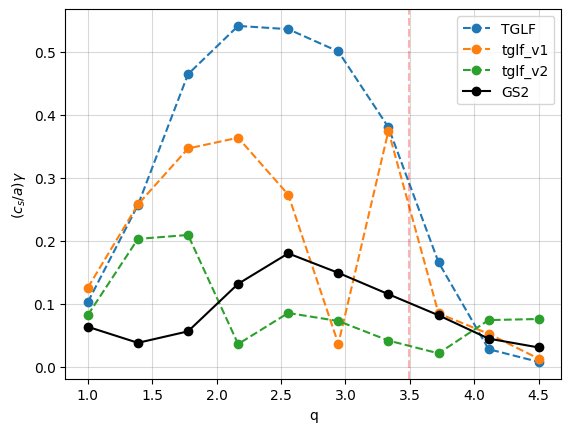

In [15]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "scan_q"
case = "S1_3"
ky = 0.3
reference_q = 3.49


for tglf in tglf_versions:
    (tglf_project_dict[project][case][tglf]
        .gk_output["growth_rate"]
        .sel(ky=ky, method="nearest")
        .sel(mode=0)
        .plot(label=tglf, marker="o", linestyle="--"))

gs2_growth_rate = (project_dict[project][case]
    .gk_output["growth_rate"]
    .sel(ky=ky, method="nearest"))
gs2_growth_rate_tolerance = (project_dict[project][case]
    .gk_output["growth_rate_tolerance"]
    .sel(ky=ky, method="nearest"))
#gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance < 0.5)

# Gaussian_Model = gs2_gp(pyro=project_dict[project][case],
#                        models_path=models_path, models=models)
# gp = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="value")
#     .sel(ky=ky, method="nearest"))
# gp_max = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="max_value")
#     .sel(ky=ky, method="nearest"))
# gp_min = (Gaussian_Model.gk_output["growth_rate"]
#     .sel(output="min_value")
#     .sel(ky=ky, method="nearest"))

# gp.plot(label="GS2-GP", marker="o", linestyle="--")
# plt.fill_between(gp["q"].values, gp_min.values, gp_max.values, color="blue", alpha=0.2, label="GS2-GP Uncertainty")
gs2_growth_rate.plot(label="GS2", color="black", marker="o")

ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

#plt.title(f"Growth Rate vs q — {case}, ky={ky_actual:.3f}")
plt.title("")
plt.xlabel("q")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



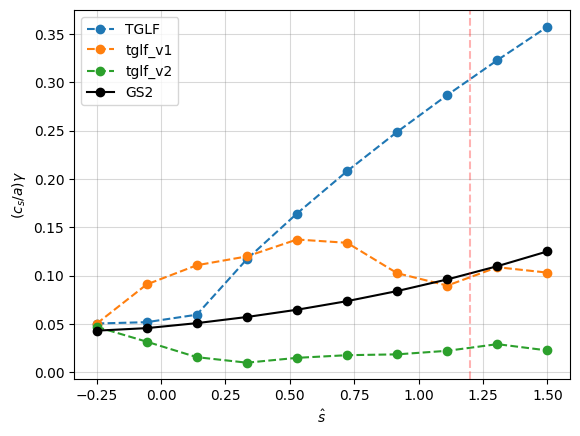

In [16]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_shat"
case = "S1_3"
ky = 0.3
reference_q = 1.2


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.1)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.xlabel(r"$\hat{s}$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs shat — {case}, ky={ky_actual:.3f}.png", dpi=300)



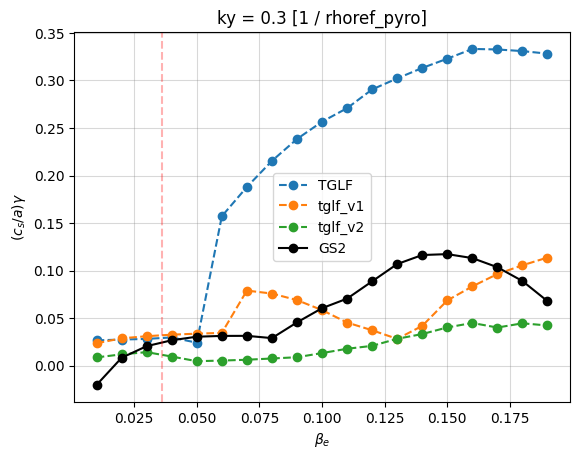

In [17]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "R3"
ky = 0.3
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_growth_rate = project_dict[project][case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_growth_rate = gs2_growth_rate.where(gs2_growth_rate_tolerance<0.1)
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

#plt.title("")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

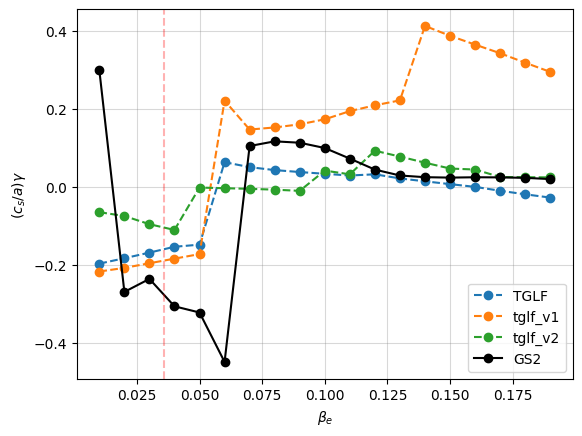

In [19]:
from matplotlib import pyplot as plt
# Plot shat scan
project = "scan_beta"
case = "R3"
ky = 0.3
reference_q = 0.036


for tglf in tglf_versions:
    tglf_project_dict[project][case][tglf].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = tglf,marker = "o",linestyle = "--")

gs2_mode_frequency = project_dict[project][case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest")
gs2_mode_frequency_tolerance = project_dict[project][case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
#gs2_mode_frequency = gs2_mode_frequency.where(gs2_mode_frequency_tolerance<0.1)
gs2_mode_frequency.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    project_dict[project][case].gk_output["mode_frequency"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/mode_frequency vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)